In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q kagglehub

In [ ]:
import torch
import torchvision
import cv2
import numpy as np

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
OpenCV: 4.13.0
NumPy: 2.0.2
CUDA: True
GPU: Tesla T4


In [ ]:
import os

os.makedirs("/content/deepfake_project", exist_ok=True)

print("Project directory created:")
print("/content/deepfake_project")

Project directory created:
/content/deepfake_project


In [ ]:
%cd /content/deepfake_project

/content/deepfake_project


In [ ]:
import kagglehub

# Download the latest version
path = kagglehub.dataset_download(
    "ucimachinelearning/deep-fake-detection-cropped-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 666M/666M [00:05<00:00, 129MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['DFDC_Dataset']


In [ ]:
print("Path:", path)
print(os.listdir(path))

Path: /root/.cache/kagglehub/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset/versions/1
['DFDC_Dataset']


In [ ]:
import os

dataset_path = os.path.join(path, "DFDC_Dataset")

print("Dataset path:")
print(dataset_path)

print("\nContents:")
for item in os.listdir(dataset_path):
    print(item)

Dataset path:
/root/.cache/kagglehub/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset/versions/1/DFDC_Dataset

Contents:
Fake
Real


In [ ]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        for file in files[:5]:
            print(f"{indent}    {file}")

DFDC_Dataset/
    Fake/
        dkqwmjuvky.mp4
        ecjozlfeec.mp4
        dhpbcfmalj.mp4
        bseaalaspv.mp4
        cyxfegxaea.mp4
    Real/
        uzirqfsjnm.mp4
        czzfgvkhah.mp4
        tvihzkjdmm.mp4
        rfakffjumr.mp4
        ekvvevzkyu.mp4


In [ ]:
import os

fake_path = os.path.join(dataset_path, "Fake")
real_path = os.path.join(dataset_path, "Real")

fake_videos = [
    f for f in os.listdir(fake_path)
    if f.lower().endswith(".mp4")
]

real_videos = [
    f for f in os.listdir(real_path)
    if f.lower().endswith(".mp4")
]

print("Fake videos:", len(fake_videos))
print("Real videos:", len(real_videos))
print("Total videos:", len(fake_videos) + len(real_videos))

Fake videos: 1566
Real videos: 1727
Total videos: 3293


In [ ]:
import os

base_dir = "/content/deepfake_project"

folders = [
    "frames/train/real",
    "frames/train/fake",
    "frames/val/real",
    "frames/val/fake",
    "frames/test/real",
    "frames/test/fake"
]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [ ]:
for root, dirs, files in os.walk(os.path.join(base_dir, "frames")):
    level = root.replace(os.path.join(base_dir, "frames"), "").count(os.sep)
    if level <= 2:
        print(root)

/content/deepfake_project/frames
/content/deepfake_project/frames/val
/content/deepfake_project/frames/val/real
/content/deepfake_project/frames/val/fake
/content/deepfake_project/frames/train
/content/deepfake_project/frames/train/real
/content/deepfake_project/frames/train/fake
/content/deepfake_project/frames/test
/content/deepfake_project/frames/test/real
/content/deepfake_project/frames/test/fake


In [ ]:
import os
import random

random.seed(42)

# Paths to original videos
fake_path = os.path.join(dataset_path, "Fake")
real_path = os.path.join(dataset_path, "Real")

# Get video filenames
fake_videos = [
    f for f in os.listdir(fake_path)
    if f.lower().endswith(".mp4")
]

real_videos = [
    f for f in os.listdir(real_path)
    if f.lower().endswith(".mp4")
]

# Shuffle
random.shuffle(fake_videos)
random.shuffle(real_videos)

# Select 600 from each class
fake_videos = fake_videos[:600]
real_videos = real_videos[:600]

# Split function
def split_videos(videos):
    train = videos[:480]
    val = videos[480:540]
    test = videos[540:600]
    return train, val, test

fake_train, fake_val, fake_test = split_videos(fake_videos)
real_train, real_val, real_test = split_videos(real_videos)

print("FAKE:")
print("Train:", len(fake_train))
print("Validation:", len(fake_val))
print("Test:", len(fake_test))

print("\nREAL:")
print("Train:", len(real_train))
print("Validation:", len(real_val))
print("Test:", len(real_test))

FAKE:
Train: 480
Validation: 60
Test: 60

REAL:
Train: 480
Validation: 60
Test: 60


In [ ]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Face detector loaded:", not face_cascade.empty())

Face detector loaded: True


In [ ]:
import cv2
import os

test_video = os.path.join(fake_path, fake_train[0])

cap = cv2.VideoCapture(test_video)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print("Video:", fake_train[0])
print("Total frames:", total_frames)
print("FPS:", fps)

cap.release()

Video: aabdnomlru.mp4
Total frames: 148
FPS: 30.0


In [ ]:
import cv2
import os

def extract_faces_from_video(video_path, output_dir, video_name, num_frames=5):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return 0

    # Select equally spaced frame numbers
    frame_indices = [
        int(i * (total_frames - 1) / (num_frames - 1))
        for i in range(num_frames)
    ]

    saved = 0

    for frame_index in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

        success, frame = cap.read()

        if not success:
            continue

        # Convert to grayscale for Haar face detector
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(80, 80)
        )

        if len(faces) == 0:
            continue

        # Select the largest detected face
        x, y, w, h = max(
            faces,
            key=lambda box: box[2] * box[3]
        )

        # Add a small margin around face
        margin = int(0.2 * max(w, h))

        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(frame.shape[1], x + w + margin)
        y2 = min(frame.shape[0], y + h + margin)

        face_crop = frame[y1:y2, x1:x2]

        # Resize for EfficientNet later
        face_crop = cv2.resize(face_crop, (224, 224))

        filename = f"{video_name}_frame{frame_index}.jpg"

        save_path = os.path.join(output_dir, filename)

        cv2.imwrite(save_path, face_crop)

        saved += 1

    cap.release()

    return saved

In [ ]:
test_output = os.path.join(
    base_dir,
    "frames",
    "train",
    "fake"
)

saved = extract_faces_from_video(
    os.path.join(fake_path, fake_train[0]),
    test_output,
    fake_train[0].replace(".mp4", ""),
    num_frames=5
)

print("Faces saved:", saved)

Faces saved: 1


In [ ]:
import urllib.request

model_url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
model_path = "/content/face_detection_yunet_2023mar.onnx"

urllib.request.urlretrieve(model_url, model_path)

print("YuNet model downloaded!")

YuNet model downloaded!


In [ ]:
import cv2

yunet = cv2.FaceDetectorYN.create(
    model_path,
    "",
    (320, 320),
    0.6,
    0.3,
    5000
)

print("YuNet initialized successfully!")

YuNet initialized successfully!


In [ ]:
import cv2
import os

def extract_faces_yunet(video_path, output_dir, video_name, num_frames=5):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return 0

    frame_indices = [
        int(i * (total_frames - 1) / (num_frames - 1))
        for i in range(num_frames)
    ]

    saved = 0

    for frame_index in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        success, frame = cap.read()

        if not success:
            continue

        height, width = frame.shape[:2]

        # Tell YuNet the current image size
        yunet.setInputSize((width, height))

        _, detections = yunet.detect(frame)

        if detections is None:
            continue

        # Detection format:
        # [x, y, width, height, confidence, ...]
        valid_faces = [
            detection for detection in detections
            if detection[14] >= 0.6
        ]

        if not valid_faces:
            continue

        # Select largest detected face
        face = max(
            valid_faces,
            key=lambda d: d[2] * d[3]
        )

        x, y, w, h = face[:4]

        x, y, w, h = map(int, [x, y, w, h])

        # Add 20% margin
        margin = int(0.2 * max(w, h))

        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(width, x + w + margin)
        y2 = min(height, y + h + margin)

        face_crop = frame[y1:y2, x1:x2]

        if face_crop.size == 0:
            continue

        # EfficientNet input size
        face_crop = cv2.resize(face_crop, (224, 224))

        filename = f"{video_name}_frame{frame_index}.jpg"

        save_path = os.path.join(output_dir, filename)

        cv2.imwrite(save_path, face_crop)

        saved += 1

    cap.release()

    return saved

In [ ]:
import glob

for file in glob.glob(os.path.join(test_output, "*.jpg")):
    os.remove(file)

print("Old test crops removed.")

Old test crops removed.


In [ ]:
saved = extract_faces_yunet(
    os.path.join(fake_path, fake_train[0]),
    test_output,
    fake_train[0].replace(".mp4", ""),
    num_frames=5
)

print("Faces saved with YuNet:", saved)

Faces saved with YuNet: 5


Images: 5


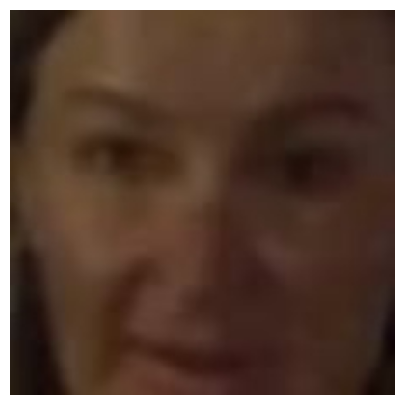

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

images = glob.glob(os.path.join(test_output, "*.jpg"))

print("Images:", len(images))

if images:
    img = Image.open(images[0])

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
test_real_output = os.path.join(
    base_dir,
    "frames",
    "train",
    "real"
)

saved_real = extract_faces_yunet(
    os.path.join(real_path, real_train[0]),
    test_real_output,
    real_train[0].replace(".mp4", ""),
    num_frames=5
)

print("Real faces saved:", saved_real)

Real faces saved: 5


In [ ]:
import os
import time

def process_video_list(video_list, source_dir, output_dir, label):
    total_saved = 0
    total_videos = len(video_list)

    start_time = time.time()

    for i, video_name in enumerate(video_list):

        video_path = os.path.join(source_dir, video_name)

        saved = extract_faces_yunet(
            video_path,
            output_dir,
            video_name.replace(".mp4", ""),
            num_frames=5
        )

        total_saved += saved

        # Progress information
        if (i + 1) % 20 == 0 or i == 0:
            elapsed = time.time() - start_time

            print(
                f"{label}: {i + 1}/{total_videos} videos | "
                f"faces saved: {total_saved} | "
                f"time: {elapsed:.1f}s"
            )

    return total_saved

In [ ]:
train_fake_saved = process_video_list(
    fake_train,
    fake_path,
    os.path.join(base_dir, "frames/train/fake"),
    "Fake Train"
)

train_real_saved = process_video_list(
    real_train,
    real_path,
    os.path.join(base_dir, "frames/train/real"),
    "Real Train"
)

print("\nTraining extraction complete!")
print("Fake faces:", train_fake_saved)
print("Real faces:", train_real_saved)

Fake Train: 1/480 videos | faces saved: 5 | time: 0.0s
Fake Train: 20/480 videos | faces saved: 98 | time: 0.4s
Fake Train: 40/480 videos | faces saved: 198 | time: 0.8s
Fake Train: 60/480 videos | faces saved: 296 | time: 1.1s
Fake Train: 80/480 videos | faces saved: 396 | time: 1.5s
Fake Train: 100/480 videos | faces saved: 496 | time: 1.9s
Fake Train: 120/480 videos | faces saved: 596 | time: 2.3s
Fake Train: 140/480 videos | faces saved: 696 | time: 2.7s
Fake Train: 160/480 videos | faces saved: 795 | time: 3.0s
Fake Train: 180/480 videos | faces saved: 894 | time: 3.4s
Fake Train: 200/480 videos | faces saved: 992 | time: 3.8s
Fake Train: 220/480 videos | faces saved: 1092 | time: 4.2s
Fake Train: 240/480 videos | faces saved: 1191 | time: 4.6s
Fake Train: 260/480 videos | faces saved: 1290 | time: 5.1s
Fake Train: 280/480 videos | faces saved: 1389 | time: 5.7s
Fake Train: 300/480 videos | faces saved: 1489 | time: 6.2s
Fake Train: 320/480 videos | faces saved: 1589 | time: 6.8s


In [ ]:
val_fake_saved = process_video_list(
    fake_val,
    fake_path,
    os.path.join(base_dir, "frames/val/fake"),
    "Fake Val"
)

val_real_saved = process_video_list(
    real_val,
    real_path,
    os.path.join(base_dir, "frames/val/real"),
    "Real Val"
)

print("\nValidation extraction complete!")
print("Fake faces:", val_fake_saved)
print("Real faces:", val_real_saved)

Fake Val: 1/60 videos | faces saved: 5 | time: 0.0s
Fake Val: 20/60 videos | faces saved: 100 | time: 0.5s
Fake Val: 40/60 videos | faces saved: 199 | time: 1.2s
Fake Val: 60/60 videos | faces saved: 298 | time: 1.7s
Real Val: 1/60 videos | faces saved: 5 | time: 0.0s
Real Val: 20/60 videos | faces saved: 94 | time: 0.5s
Real Val: 40/60 videos | faces saved: 190 | time: 1.1s
Real Val: 60/60 videos | faces saved: 290 | time: 1.6s

Validation extraction complete!
Fake faces: 298
Real faces: 290


In [ ]:
test_fake_saved = process_video_list(
    fake_test,
    fake_path,
    os.path.join(base_dir, "frames/test/fake"),
    "Fake Test"
)

test_real_saved = process_video_list(
    real_test,
    real_path,
    os.path.join(base_dir, "frames/test/real"),
    "Real Test"
)

print("\nTesting extraction complete!")
print("Fake faces:", test_fake_saved)
print("Real faces:", test_real_saved)

Fake Test: 1/60 videos | faces saved: 5 | time: 0.1s
Fake Test: 20/60 videos | faces saved: 96 | time: 0.8s
Fake Test: 40/60 videos | faces saved: 196 | time: 2.3s
Fake Test: 60/60 videos | faces saved: 295 | time: 3.6s
Real Test: 1/60 videos | faces saved: 5 | time: 0.0s
Real Test: 20/60 videos | faces saved: 100 | time: 0.9s
Real Test: 40/60 videos | faces saved: 199 | time: 1.2s
Real Test: 60/60 videos | faces saved: 298 | time: 1.6s

Testing extraction complete!
Fake faces: 295
Real faces: 298


In [ ]:
import os

def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

for split in ["train", "val", "test"]:
    fake_count = count_images(
        os.path.join(base_dir, "frames", split, "fake")
    )

    real_count = count_images(
        os.path.join(base_dir, "frames", split, "real")
    )

    print(f"{split.upper()}:")
    print("  Fake:", fake_count)
    print("  Real:", real_count)
    print("  Total:", fake_count + real_count)

TRAIN:
  Fake: 2380
  Real: 2385
  Total: 4765
VAL:
  Fake: 298
  Real: 290
  Total: 588
TEST:
  Fake: 295
  Real: 298
  Total: 593


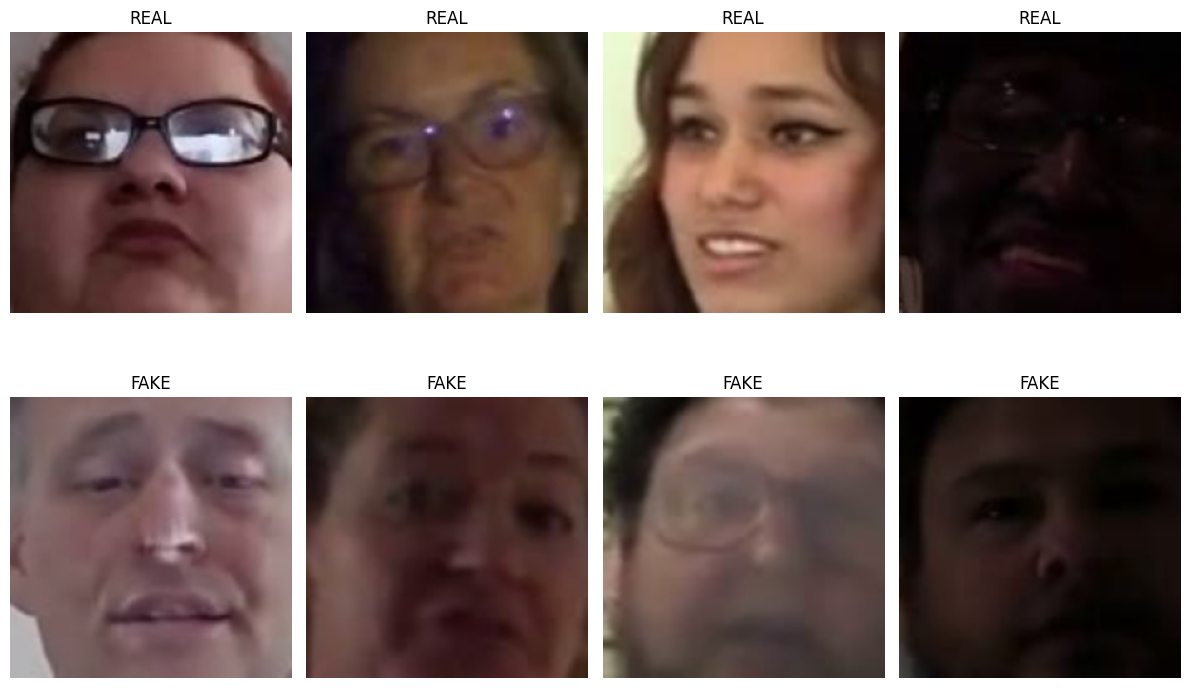

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import glob

real_images = glob.glob(
    os.path.join(base_dir, "frames/train/real/*.jpg")
)

fake_images = glob.glob(
    os.path.join(base_dir, "frames/train/fake/*.jpg")
)

samples = (
    random.sample(real_images, min(4, len(real_images))) +
    random.sample(fake_images, min(4, len(fake_images)))
)

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(samples):
    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")

    if i < 4:
        plt.title("REAL")
    else:
        plt.title("FAKE")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [ ]:
train_dataset = datasets.ImageFolder(
    os.path.join(base_dir, "frames/train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(base_dir, "frames/val"),
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(base_dir, "frames/test"),
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))

Classes: ['fake', 'real']
Training images: 4765
Validation images: 588
Testing images: 593


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready!")

DataLoaders ready!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

# Replace the final classification layer
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 121MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

print("Loss function, optimizer and scheduler ready.")

Loss function, optimizer and scheduler ready.


In [ ]:
scaler = torch.amp.GradScaler("cuda")

print("Mixed precision training enabled.")

Mixed precision training enabled.


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
import time

num_epochs = 5

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(num_epochs):

    start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_accuracy)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy*100:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy*100:.2f}% "
        f"| Time: {epoch_time:.1f}s"
    )

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            os.path.join(
                base_dir,
                "best_deepfake_model.pth"
            )
        )

        print("  ✓ Best model saved!")

Epoch [1/5] | Train Loss: 0.5771 | Train Acc: 69.51% | Val Loss: 0.6703 | Val Acc: 67.86% | Time: 49.6s
  ✓ Best model saved!
Epoch [2/5] | Train Loss: 0.4162 | Train Acc: 81.05% | Val Loss: 0.5567 | Val Acc: 76.36% | Time: 24.8s
  ✓ Best model saved!
Epoch [3/5] | Train Loss: 0.3136 | Train Acc: 86.32% | Val Loss: 0.6017 | Val Acc: 76.19% | Time: 23.8s
Epoch [4/5] | Train Loss: 0.2262 | Train Acc: 90.70% | Val Loss: 0.5606 | Val Acc: 77.72% | Time: 24.5s
  ✓ Best model saved!
Epoch [5/5] | Train Loss: 0.1926 | Train Acc: 92.30% | Val Loss: 0.6350 | Val Acc: 78.23% | Time: 24.3s
  ✓ Best model saved!


In [ ]:
best_model_path = os.path.join(
    base_dir,
    "best_deepfake_model.pth"
)

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("Best model loaded.")
print("Best validation accuracy:",
      f"{best_val_accuracy * 100:.2f}%")

Best model loaded.
Best validation accuracy: 78.23%


In [ ]:
import numpy as np

all_labels = []
all_predictions = []
all_probabilities = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

print("Predictions generated!")
print("Test samples:", len(all_labels))

Predictions generated!
Test samples: 593


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes
    )
)

Accuracy : 87.35%
Precision: 86.80%
Recall   : 88.26%
F1 Score : 87.52%
ROC-AUC  : 0.9374

Classification Report:
              precision    recall  f1-score   support

        fake       0.88      0.86      0.87       295
        real       0.87      0.88      0.88       298

    accuracy                           0.87       593
   macro avg       0.87      0.87      0.87       593
weighted avg       0.87      0.87      0.87       593



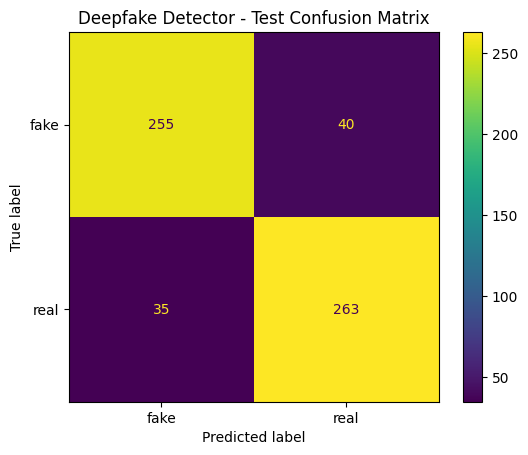

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot()

plt.title("Deepfake Detector - Test Confusion Matrix")
plt.show()

In [ ]:
from collections import defaultdict
import os
import numpy as np

# Map each test image to its original video
video_predictions = defaultdict(list)

test_fake_dir = os.path.join(
    base_dir,
    "frames/test/fake"
)

test_real_dir = os.path.join(
    base_dir,
    "frames/test/real"
)

# Get all test image paths
test_image_paths = (
    [
        os.path.join(test_fake_dir, f)
        for f in os.listdir(test_fake_dir)
        if f.endswith(".jpg")
    ]
    +
    [
        os.path.join(test_real_dir, f)
        for f in os.listdir(test_real_dir)
        if f.endswith(".jpg")
    ]
)

print("Test face crops:", len(test_image_paths))

Test face crops: 593


In [ ]:
def predict_face(image_path):

    image = Image.open(image_path).convert("RGB")

    image_tensor = val_test_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

    # Class 0 = fake
    fake_probability = probabilities[0][0].item()

    return fake_probability

In [ ]:
for image_path in test_image_paths:

    filename = os.path.basename(image_path)

    # Remove "_frameXXXX.jpg"
    video_name = filename.split("_frame")[0]

    fake_probability = predict_face(image_path)

    video_predictions[video_name].append(
        fake_probability
    )

print("Videos evaluated:", len(video_predictions))

Videos evaluated: 120


In [ ]:
video_results = []

for video_name, probabilities in video_predictions.items():

    average_fake_probability = np.mean(
        probabilities
    )

    if average_fake_probability >= 0.5:
        prediction = "FAKE"
    else:
        prediction = "REAL"

    video_results.append({
        "video": video_name,
        "frames": len(probabilities),
        "fake_probability": average_fake_probability,
        "prediction": prediction
    })

print("Video-level predictions generated!")

Video-level predictions generated!


In [ ]:
for result in video_results[:10]:

    print(
        result["video"],
        "| Frames:", result["frames"],
        "| Fake probability:",
        f"{result['fake_probability']*100:.2f}%",
        "| Prediction:",
        result["prediction"]
    )

akpuczgfpk | Frames: 5 | Fake probability: 80.66% | Prediction: FAKE
caolfufjvz | Frames: 5 | Fake probability: 99.81% | Prediction: FAKE
cmqjpitmyj | Frames: 5 | Fake probability: 95.30% | Prediction: FAKE
aysrnwnhii | Frames: 5 | Fake probability: 25.87% | Prediction: REAL
birhfcgkot | Frames: 5 | Fake probability: 53.94% | Prediction: FAKE
ctjgmxfaxe | Frames: 5 | Fake probability: 98.46% | Prediction: FAKE
dffscprcuu | Frames: 5 | Fake probability: 83.01% | Prediction: FAKE
cudbbhoegh | Frames: 5 | Fake probability: 85.31% | Prediction: FAKE
axcasmwtjb | Frames: 5 | Fake probability: 97.51% | Prediction: FAKE
dgrmcxvcok | Frames: 5 | Fake probability: 98.27% | Prediction: FAKE


In [ ]:
# Create ground-truth labels for test videos

ground_truth = {}

for video_name in fake_test:
    ground_truth[video_name.replace(".mp4", "")] = 0  # FAKE

for video_name in real_test:
    ground_truth[video_name.replace(".mp4", "")] = 1  # REAL

print("Ground-truth videos:", len(ground_truth))

Ground-truth videos: 120


In [ ]:
video_labels = []
video_predictions_binary = []
video_fake_probabilities = []

for result in video_results:

    video_name = result["video"]

    if video_name not in ground_truth:
        continue

    true_label = ground_truth[video_name]

    # Our prediction:
    # fake probability >= 0.5 → FAKE (0)
    # fake probability < 0.5 → REAL (1)

    fake_probability = result["fake_probability"]

    predicted_label = (
        0 if fake_probability >= 0.5 else 1
    )

    video_labels.append(true_label)
    video_predictions_binary.append(predicted_label)
    video_fake_probabilities.append(fake_probability)

print("Videos evaluated:", len(video_labels))

Videos evaluated: 120


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

video_accuracy = accuracy_score(
    video_labels,
    video_predictions_binary
)

video_precision = precision_score(
    video_labels,
    video_predictions_binary,
    pos_label=1
)

video_recall = recall_score(
    video_labels,
    video_predictions_binary,
    pos_label=1
)

video_f1 = f1_score(
    video_labels,
    video_predictions_binary,
    pos_label=1
)

# Convert fake probability to "real probability"
real_probabilities = [
    1 - p for p in video_fake_probabilities
]

video_roc_auc = roc_auc_score(
    video_labels,
    real_probabilities
)

print(f"Video Accuracy : {video_accuracy * 100:.2f}%")
print(f"Video Precision: {video_precision * 100:.2f}%")
print(f"Video Recall   : {video_recall * 100:.2f}%")
print(f"Video F1 Score : {video_f1 * 100:.2f}%")
print(f"Video ROC-AUC  : {video_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        video_labels,
        video_predictions_binary,
        target_names=["fake", "real"]
    )
)

Video Accuracy : 89.17%
Video Precision: 88.52%
Video Recall   : 90.00%
Video F1 Score : 89.26%
Video ROC-AUC  : 0.9597

Classification Report:
              precision    recall  f1-score   support

        fake       0.90      0.88      0.89        60
        real       0.89      0.90      0.89        60

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120



In [ ]:
cm = confusion_matrix(
    video_labels,
    video_predictions_binary
)

print("Video-level Confusion Matrix:")
print(cm)

Video-level Confusion Matrix:
[[53  7]
 [ 6 54]]


In [3]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

PROJECT_DIR = "/content/drive/MyDrive/DeepfakeDetector"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Exists:", os.path.exists(PROJECT_DIR))

Project folder: /content/drive/MyDrive/DeepfakeDetector
Exists: True


In [6]:
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'IMG-20250327-WA0029.jpg', 'Getting started.pdf', '1573316778628blob.jpg', 'Sample-Paper-ASAT-IX.pdf', 'Disaster Management (Autosaved).docx', 'Ch2.maths', 'chaudhry real no.pdf', 'sst Chapter 1.pdf', 'f3dChapter 2.pdf', 'New Doc 04-01-2020 21.14.58.pdf', 'Untitled presentation (1).gslides', 'Untitled presentation.gslides', 'report.pdf', 'Classroom', 'Chapter 4. Agriculture.gdoc', 'The Ball Poem.gdoc', 'Acids, bases and salts.docx', 'Expression Series circular (1).gdoc', 'Expression Series circular.gdoc', 'IMG-20200718-WA0001.jpg', 'X - Polynomials - Question Paper.gdoc', 'test2 (1).pdf', 'test2.pdf', 'NTSE GURU.gdoc', 'Presentation1 (1).gslides', 'test2.gdoc', 'Gap filling IX and X (2).gdoc', 'Gap filling IX and X (1).gdoc', 'Gap filling IX and X.docx', 'Answers  gap filling IX X.gdoc', 'Gap filling IX and X.gdoc', 'P1bio.pdf', 'money credt que ans (1).gdoc', 'money credt que ans.gdoc', 'Presentation1.gslides', 'PROJECT-WORK-2020-21 SOCIAL SCIENCE (GEOGRAPHY) CLASS

In [7]:
import os

PROJECT_DIR = "/content/drive/MyDrive/DeepfakeDetector"

folders = [
    "frames",
    "frames/train",
    "frames/train/fake",
    "frames/train/real",
    "frames/val",
    "frames/val/fake",
    "frames/val/real",
    "frames/test",
    "frames/test/fake",
    "frames/test/real",
    "models",
    "results"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("Project structure created!")
print(PROJECT_DIR)

Project structure created!
/content/drive/MyDrive/DeepfakeDetector


In [8]:
print(os.listdir(PROJECT_DIR))

['frames', 'models', 'results']


In [9]:
!pip install -q kagglehub

In [10]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download(
    "ucimachinelearning/deep-fake-detection-cropped-dataset"
)

print("Dataset downloaded!")
print("Path:", dataset_path)
print(os.listdir(dataset_path))

100%|██████████| 666M/666M [00:07<00:00, 93.6MB/s]

Extracting files...


Dataset downloaded!
Path: /root/.cache/kagglehub/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset/versions/1
['DFDC_Dataset']


In [11]:
import os

dataset_root = os.path.join(
    dataset_path,
    "DFDC_Dataset"
)

fake_dir = os.path.join(dataset_root, "Fake")
real_dir = os.path.join(dataset_root, "Real")

print("Fake videos:", len(os.listdir(fake_dir)))
print("Real videos:", len(os.listdir(real_dir)))


Fake videos: 1566
Real videos: 1727


In [12]:
train_dir = os.path.join(PROJECT_DIR, "frames", "train")
val_dir   = os.path.join(PROJECT_DIR, "frames", "val")
test_dir  = os.path.join(PROJECT_DIR, "frames", "test")

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /content/drive/MyDrive/DeepfakeDetector/frames/train
Validation: /content/drive/MyDrive/DeepfakeDetector/frames/val
Test: /content/drive/MyDrive/DeepfakeDetector/frames/test


In [13]:
import os
import random

# Get video filenames
fake_videos = [
    f for f in os.listdir(fake_dir)
    if f.lower().endswith(".mp4")
]

real_videos = [
    f for f in os.listdir(real_dir)
    if f.lower().endswith(".mp4")
]

# Fixed seed so the split is reproducible
random.seed(42)

random.shuffle(fake_videos)
random.shuffle(real_videos)

# Same split we used yesterday:
# 480 train + 60 validation + 60 test for each class

fake_train = fake_videos[:480]
fake_val   = fake_videos[480:540]
fake_test  = fake_videos[540:600]

real_train = real_videos[:480]
real_val   = real_videos[480:540]
real_test  = real_videos[540:600]

print("FAKE:")
print("Train:", len(fake_train))
print("Validation:", len(fake_val))
print("Test:", len(fake_test))

print("\nREAL:")
print("Train:", len(real_train))
print("Validation:", len(real_val))
print("Test:", len(real_test))

FAKE:
Train: 480
Validation: 60
Test: 60

REAL:
Train: 480
Validation: 60
Test: 60


In [14]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [15]:
import os
import urllib.request

yunet_path = os.path.join(PROJECT_DIR, "yunet.onnx")

if not os.path.exists(yunet_path):
    url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
    urllib.request.urlretrieve(url, yunet_path)
    print("YuNet model downloaded!")
else:
    print("YuNet already exists!")

print("YuNet path:", yunet_path)

YuNet model downloaded!
YuNet path: /content/drive/MyDrive/DeepfakeDetector/yunet.onnx


In [16]:
yunet = cv2.FaceDetectorYN.create(
    yunet_path,
    "",
    (320, 320),
    0.6,
    0.3,
    5000
)

print("YuNet initialized successfully!")

YuNet initialized successfully!


Video: cvxnllaicc.mp4
Total frames: 148
FPS: 30.0
Faces detected: 1


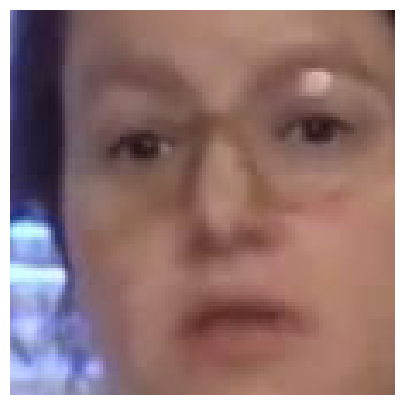

In [17]:
import os
import cv2
import matplotlib.pyplot as plt

# Take the first fake training video
test_video = os.path.join(fake_dir, fake_train[0])

cap = cv2.VideoCapture(test_video)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print("Video:", os.path.basename(test_video))
print("Total frames:", total_frames)
print("FPS:", fps)

# Read the middle frame
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
ret, frame = cap.read()
cap.release()

if not ret:
    print("Could not read video!")
else:
    # YuNet expects width/height to be set
    h, w = frame.shape[:2]
    yunet.setInputSize((w, h))

    _, faces = yunet.detect(frame)

    if faces is not None:
        print("Faces detected:", len(faces))
    else:
        print("No face detected")

    # Convert BGR → RGB for displaying
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

In [18]:
import os
import cv2
import time

def extract_faces_from_videos(
    videos,
    video_dir,
    output_dir,
    label,
    frames_per_video=5
):
    os.makedirs(output_dir, exist_ok=True)

    total_faces = 0
    start_time = time.time()

    for i, video_name in enumerate(videos):

        video_path = os.path.join(video_dir, video_name)

        cap = cv2.VideoCapture(video_path)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            cap.release()
            continue

        # Select evenly spaced frames
        frame_indices = [
            int(x)
            for x in __import__("numpy").linspace(
                0,
                total_frames - 1,
                frames_per_video
            )
        ]

        video_faces = 0

        for frame_idx in frame_indices:

            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

            ret, frame = cap.read()

            if not ret:
                continue

            h, w = frame.shape[:2]

            # Tell YuNet the current image size
            yunet.setInputSize((w, h))

            _, faces = yunet.detect(frame)

            if faces is None:
                continue

            # Select the largest detected face
            largest_face = max(
                faces,
                key=lambda f: f[2] * f[3]
            )

            x, y, fw, fh = largest_face[:4]

            x = max(0, int(x))
            y = max(0, int(y))
            fw = int(fw)
            fh = int(fh)

            x2 = min(w, x + fw)
            y2 = min(h, y + fh)

            if x2 <= x or y2 <= y:
                continue

            face_crop = frame[y:y2, x:x2]

            if face_crop.size == 0:
                continue

            # Resize for EfficientNet
            face_crop = cv2.resize(
                face_crop,
                (224, 224)
            )

            # Unique filename
            output_name = (
                f"{label}_{i:04d}_{frame_idx:06d}.jpg"
            )

            output_path = os.path.join(
                output_dir,
                output_name
            )

            cv2.imwrite(
                output_path,
                face_crop
            )

            total_faces += 1
            video_faces += 1

        cap.release()

        if (i + 1) % 20 == 0 or i == 0:
            elapsed = time.time() - start_time

            print(
                f"{label}: {i+1}/{len(videos)} videos | "
                f"faces saved: {total_faces} | "
                f"time: {elapsed:.1f}s"
            )

    print(f"\n{label} extraction complete!")
    print(f"Total faces saved: {total_faces}")

    return total_faces

In [19]:
fake_train_faces = extract_faces_from_videos(
    videos=fake_train,
    video_dir=fake_dir,
    output_dir=os.path.join(train_dir, "fake"),
    label="Fake Train",
    frames_per_video=5
)

print("Fake Train faces:", fake_train_faces)

Fake Train: 1/480 videos | faces saved: 5 | time: 0.2s
Fake Train: 20/480 videos | faces saved: 100 | time: 2.5s
Fake Train: 40/480 videos | faces saved: 200 | time: 4.3s
Fake Train: 60/480 videos | faces saved: 300 | time: 5.3s
Fake Train: 80/480 videos | faces saved: 394 | time: 6.3s
Fake Train: 100/480 videos | faces saved: 494 | time: 7.3s
Fake Train: 120/480 videos | faces saved: 594 | time: 8.4s
Fake Train: 140/480 videos | faces saved: 694 | time: 9.4s
Fake Train: 160/480 videos | faces saved: 794 | time: 10.5s
Fake Train: 180/480 videos | faces saved: 894 | time: 11.7s
Fake Train: 200/480 videos | faces saved: 994 | time: 13.0s
Fake Train: 220/480 videos | faces saved: 1092 | time: 14.4s
Fake Train: 240/480 videos | faces saved: 1192 | time: 15.7s
Fake Train: 260/480 videos | faces saved: 1291 | time: 16.7s
Fake Train: 280/480 videos | faces saved: 1391 | time: 17.8s
Fake Train: 300/480 videos | faces saved: 1491 | time: 18.8s
Fake Train: 320/480 videos | faces saved: 1591 | ti

In [20]:
real_train_faces = extract_faces_from_videos(
    videos=real_train,
    video_dir=real_dir,
    output_dir=os.path.join(train_dir, "real"),
    label="Real Train",
    frames_per_video=5
)

print("Real Train faces:", real_train_faces)

Real Train: 1/480 videos | faces saved: 5 | time: 0.1s
Real Train: 20/480 videos | faces saved: 100 | time: 1.7s
Real Train: 40/480 videos | faces saved: 200 | time: 3.3s
Real Train: 60/480 videos | faces saved: 296 | time: 4.6s
Real Train: 80/480 videos | faces saved: 396 | time: 6.1s
Real Train: 100/480 videos | faces saved: 495 | time: 7.6s
Real Train: 120/480 videos | faces saved: 594 | time: 8.8s
Real Train: 140/480 videos | faces saved: 694 | time: 9.9s
Real Train: 160/480 videos | faces saved: 794 | time: 11.1s
Real Train: 180/480 videos | faces saved: 894 | time: 12.3s
Real Train: 200/480 videos | faces saved: 994 | time: 13.4s
Real Train: 220/480 videos | faces saved: 1094 | time: 14.6s
Real Train: 240/480 videos | faces saved: 1194 | time: 15.7s
Real Train: 260/480 videos | faces saved: 1293 | time: 16.9s
Real Train: 280/480 videos | faces saved: 1393 | time: 18.0s
Real Train: 300/480 videos | faces saved: 1493 | time: 19.5s
Real Train: 320/480 videos | faces saved: 1592 | ti

In [21]:
fake_val_faces = extract_faces_from_videos(
    videos=fake_val,
    video_dir=fake_dir,
    output_dir=os.path.join(val_dir, "fake"),
    label="Fake Val",
    frames_per_video=5
)

print("Fake Validation faces:", fake_val_faces)

Fake Val: 1/60 videos | faces saved: 5 | time: 0.2s
Fake Val: 20/60 videos | faces saved: 100 | time: 2.8s
Fake Val: 40/60 videos | faces saved: 196 | time: 4.4s
Fake Val: 60/60 videos | faces saved: 296 | time: 5.5s

Fake Val extraction complete!
Total faces saved: 296
Fake Validation faces: 296


In [22]:
real_val_faces = extract_faces_from_videos(
    videos=real_val,
    video_dir=real_dir,
    output_dir=os.path.join(val_dir, "real"),
    label="Real Val",
    frames_per_video=5
)

print("Real Validation faces:", real_val_faces)

Real Val: 1/60 videos | faces saved: 5 | time: 0.1s
Real Val: 20/60 videos | faces saved: 99 | time: 2.4s
Real Val: 40/60 videos | faces saved: 197 | time: 3.6s
Real Val: 60/60 videos | faces saved: 297 | time: 4.7s

Real Val extraction complete!
Total faces saved: 297
Real Validation faces: 297


In [23]:
fake_test_faces = extract_faces_from_videos(
    videos=fake_test,
    video_dir=fake_dir,
    output_dir=os.path.join(test_dir, "fake"),
    label="Fake Test",
    frames_per_video=5
)

print("Fake Test faces:", fake_test_faces)


Fake Test: 1/60 videos | faces saved: 5 | time: 0.1s
Fake Test: 20/60 videos | faces saved: 100 | time: 1.9s
Fake Test: 40/60 videos | faces saved: 200 | time: 3.0s
Fake Test: 60/60 videos | faces saved: 299 | time: 4.2s

Fake Test extraction complete!
Total faces saved: 299
Fake Test faces: 299


In [24]:
real_test_faces = extract_faces_from_videos(
    videos=real_test,
    video_dir=real_dir,
    output_dir=os.path.join(test_dir, "real"),
    label="Real Test",
    frames_per_video=5
)

print("Real Test faces:", real_test_faces)

Real Test: 1/60 videos | faces saved: 5 | time: 0.1s
Real Test: 20/60 videos | faces saved: 100 | time: 3.3s
Real Test: 40/60 videos | faces saved: 200 | time: 4.8s
Real Test: 60/60 videos | faces saved: 300 | time: 6.0s

Real Test extraction complete!
Total faces saved: 300
Real Test faces: 300


In [25]:
import os

print("TRAIN")
print("Fake:", len(os.listdir(os.path.join(train_dir, "fake"))))
print("Real:", len(os.listdir(os.path.join(train_dir, "real"))))

print("\nVALIDATION")
print("Fake:", len(os.listdir(os.path.join(val_dir, "fake"))))
print("Real:", len(os.listdir(os.path.join(val_dir, "real"))))

print("\nTEST")
print("Fake:", len(os.listdir(os.path.join(test_dir, "fake"))))
print("Real:", len(os.listdir(os.path.join(test_dir, "real"))))

TRAIN
Fake: 2377
Real: 2389

VALIDATION
Fake: 296
Real: 297

TEST
Fake: 299
Real: 300


In [26]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [27]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Load pretrained EfficientNet-B0
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# Replace the final classifier
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    2
)

# Move model to GPU
model = model.to(device)

print("EfficientNet-B0 loaded!")
print("Classes: FAKE / REAL")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 114MB/s] 


EfficientNet-B0 loaded!
Classes: FAKE / REAL


In [28]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created!")

Transforms created!


In [29]:
train_dataset = ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = ImageFolder(
    val_dir,
    transform=test_transform
)

test_dataset = ImageFolder(
    test_dir,
    transform=test_transform
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))

Classes: ['fake', 'real']
Training images: 4766
Validation images: 593
Testing images: 599


In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

DataLoaders ready!
Training batches: 149
Validation batches: 19
Testing batches: 19


In [31]:
import torch.optim as optim

# Loss function for binary classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Automatically reduce learning rate if validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001


In [32]:
import time

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

print("Training functions ready!")

Training functions ready!


In [33]:
import os
import time
import torch

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "best_deepfake_model.pth"
)

os.makedirs(
    os.path.dirname(MODEL_PATH),
    exist_ok=True
)

num_epochs = 5

best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("Starting training...")
print("Model will be saved to:")
print(MODEL_PATH)

for epoch in range(num_epochs):

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Time: {elapsed:.1f}s"
    )

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": train_dataset.classes,
                "val_accuracy": val_acc
            },
            MODEL_PATH
        )

        print("  ✓ Best model saved to Google Drive!")

print("\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print("Model:", MODEL_PATH)

Starting training...
Model will be saved to:
/content/drive/MyDrive/DeepfakeDetector/models/best_deepfake_model.pth
Epoch [1/5] | Train Loss: 0.5820 | Train Acc: 68.55% | Val Loss: 0.5318 | Val Acc: 73.69% | Time: 34.0s
  ✓ Best model saved to Google Drive!
Epoch [2/5] | Train Loss: 0.4147 | Train Acc: 80.63% | Val Loss: 0.4731 | Val Acc: 77.07% | Time: 31.5s
  ✓ Best model saved to Google Drive!
Epoch [3/5] | Train Loss: 0.3016 | Train Acc: 87.68% | Val Loss: 0.3984 | Val Acc: 83.31% | Time: 33.7s
  ✓ Best model saved to Google Drive!
Epoch [4/5] | Train Loss: 0.2306 | Train Acc: 90.41% | Val Loss: 0.3688 | Val Acc: 83.64% | Time: 33.4s
  ✓ Best model saved to Google Drive!
Epoch [5/5] | Train Loss: 0.1977 | Train Acc: 91.69% | Val Loss: 0.3665 | Val Acc: 85.50% | Time: 30.9s
  ✓ Best model saved to Google Drive!

Training complete!
Best validation accuracy: 85.50%
Model: /content/drive/MyDrive/DeepfakeDetector/models/best_deepfake_model.pth


In [34]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded!")
print("Validation accuracy:",
      checkpoint["val_accuracy"] * 100, "%")
print("Classes:", checkpoint["class_names"])

Best model loaded!
Validation accuracy: 85.49747048903879 %
Classes: ['fake', 'real']


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import torch

all_labels = []
all_predictions = []
all_probabilities = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        # Probability of FAKE
        all_probabilities.extend(
            probabilities[:, 0]
            .cpu()
            .numpy()
        )

# Convert to numpy
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

# Metrics
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    pos_label=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    pos_label=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    pos_label=0
)

roc_auc = roc_auc_score(
    (all_labels == 0).astype(int),
    all_probabilities
)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

Accuracy : 87.15%
Precision: 83.23%
Recall   : 92.98%
F1 Score : 87.84%
ROC-AUC  : 0.9422

Confusion Matrix:
[[278  21]
 [ 56 244]]

Classification Report:
              precision    recall  f1-score   support

        fake       0.83      0.93      0.88       299
        real       0.92      0.81      0.86       300

    accuracy                           0.87       599
   macro avg       0.88      0.87      0.87       599
weighted avg       0.88      0.87      0.87       599



In [36]:
import cv2
import numpy as np
import torch
import os

def predict_video(
    video_path,
    model,
    yunet,
    device,
    frames_to_sample=5
):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        cap.release()
        return None

    # Select evenly spaced frames
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        frames_to_sample
    ).astype(int)

    fake_probabilities = []

    model.eval()

    for frame_idx in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(frame_idx)
        )

        ret, frame = cap.read()

        if not ret:
            continue

        h, w = frame.shape[:2]

        # Configure YuNet for this frame
        yunet.setInputSize((w, h))

        _, faces = yunet.detect(frame)

        if faces is None:
            continue

        # Choose largest face
        largest_face = max(
            faces,
            key=lambda f: f[2] * f[3]
        )

        x, y, fw, fh = largest_face[:4]

        x = max(0, int(x))
        y = max(0, int(y))
        fw = int(fw)
        fh = int(fh)

        x2 = min(w, x + fw)
        y2 = min(h, y + fh)

        if x2 <= x or y2 <= y:
            continue

        face = frame[y:y2, x:x2]

        if face.size == 0:
            continue

        # OpenCV BGR → RGB
        face = cv2.cvtColor(
            face,
            cv2.COLOR_BGR2RGB
        )

        # Convert to PIL
        from PIL import Image

        face = Image.fromarray(face)

        # Apply test preprocessing
        face_tensor = test_transform(face)

        face_tensor = face_tensor.unsqueeze(0).to(device)

        # AI prediction
        with torch.no_grad():

            output = model(face_tensor)

            probability = torch.softmax(
                output,
                dim=1
            )

            # Class 0 = FAKE
            fake_probability = probability[
                0, 0
            ].item()

        fake_probabilities.append(
            fake_probability
        )

    cap.release()

    if len(fake_probabilities) == 0:
        return None

    # Average frame predictions
    average_fake_probability = np.mean(
        fake_probabilities
    )

    prediction = (
        "FAKE"
        if average_fake_probability >= 0.5
        else "REAL"
    )

    return {
        "prediction": prediction,
        "fake_probability": average_fake_probability,
        "frames_used": len(fake_probabilities)
    }

print("Video prediction function ready!")

Video prediction function ready!


In [37]:
test_video_path = os.path.join(
    fake_dir,
    fake_test[0]
)

result = predict_video(
    test_video_path,
    model,
    yunet,
    device,
    frames_to_sample=5
)

print("Video:", os.path.basename(test_video_path))
print("Result:", result)

Video: cboymxepfb.mp4
Result: {'prediction': 'FAKE', 'fake_probability': np.float64(0.5926484525203705), 'frames_used': 5}


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

video_true_labels = []
video_predictions = []
video_fake_probabilities = []

print("Testing FAKE videos...\n")

for i, video in enumerate(fake_test):

    video_path = os.path.join(
        fake_dir,
        video
    )

    result = predict_video(
        video_path,
        model,
        yunet,
        device,
        frames_to_sample=5
    )

    if result is None:
        print(f"Skipped: {video}")
        continue

    # Actual label: FAKE = 0
    video_true_labels.append(0)

    # Prediction
    prediction_label = (
        0 if result["prediction"] == "FAKE"
        else 1
    )

    video_predictions.append(
        prediction_label
    )

    video_fake_probabilities.append(
        float(result["fake_probability"])
    )

    if (i + 1) % 20 == 0:

        print(
            f"Fake videos: {i+1}/{len(fake_test)}"
        )


print("\nTesting REAL videos...\n")

for i, video in enumerate(real_test):

    video_path = os.path.join(
        real_dir,
        video
    )

    result = predict_video(
        video_path,
        model,
        yunet,
        device,
        frames_to_sample=5
    )

    if result is None:
        print(f"Skipped: {video}")
        continue

    # Actual label: REAL = 1
    video_true_labels.append(1)

    prediction_label = (
        0 if result["prediction"] == "FAKE"
        else 1
    )

    video_predictions.append(
        prediction_label
    )

    video_fake_probabilities.append(
        float(result["fake_probability"])
    )

    if (i + 1) % 20 == 0:

        print(
            f"Real videos: {i+1}/{len(real_test)}"
        )


# Convert to numpy
video_true_labels = np.array(
    video_true_labels
)

video_predictions = np.array(
    video_predictions
)

video_fake_probabilities = np.array(
    video_fake_probabilities
)

# Metrics
video_accuracy = accuracy_score(
    video_true_labels,
    video_predictions
)

video_precision = precision_score(
    video_true_labels,
    video_predictions,
    pos_label=0
)

video_recall = recall_score(
    video_true_labels,
    video_predictions,
    pos_label=0
)

video_f1 = f1_score(
    video_true_labels,
    video_predictions,
    pos_label=0
)

# Convert labels so FAKE = 1 for ROC-AUC
fake_true_labels = (
    video_true_labels == 0
).astype(int)

video_roc_auc = roc_auc_score(
    fake_true_labels,
    video_fake_probabilities
)

print("\n" + "=" * 50)
print("VIDEO-LEVEL RESULTS")
print("=" * 50)

print(
    f"Videos evaluated : {len(video_true_labels)}"
)

print(
    f"Accuracy          : {video_accuracy*100:.2f}%"
)

print(
    f"Precision         : {video_precision*100:.2f}%"
)

print(
    f"Recall            : {video_recall*100:.2f}%"
)

print(
    f"F1 Score          : {video_f1*100:.2f}%"
)

print(
    f"ROC-AUC           : {video_roc_auc:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        video_true_labels,
        video_predictions
    )
)

print("\nClassification Report:")

print(
    classification_report(
        video_true_labels,
        video_predictions,
        target_names=["fake", "real"]
    )
)

Testing FAKE videos...

Fake videos: 20/60
Fake videos: 40/60
Fake videos: 60/60

Testing REAL videos...

Real videos: 20/60
Real videos: 40/60
Real videos: 60/60

VIDEO-LEVEL RESULTS
Videos evaluated : 120
Accuracy          : 88.33%
Precision         : 92.59%
Recall            : 83.33%
F1 Score          : 87.72%
ROC-AUC           : 0.9628

Confusion Matrix:
[[50 10]
 [ 4 56]]

Classification Report:
              precision    recall  f1-score   support

        fake       0.93      0.83      0.88        60
        real       0.85      0.93      0.89        60

    accuracy                           0.88       120
   macro avg       0.89      0.88      0.88       120
weighted avg       0.89      0.88      0.88       120



In [39]:
!pip install -q gradio

In [40]:
import os

print("Model exists:", os.path.exists(MODEL_PATH))
print("Model path:", MODEL_PATH)

Model exists: True
Model path: /content/drive/MyDrive/DeepfakeDetector/models/best_deepfake_model.pth


In [41]:
def detect_deepfake(video_path):

    if video_path is None:
        return "Please upload a video.", 0.0, 0

    result = predict_video(
        video_path,
        model,
        yunet,
        device,
        frames_to_sample=5
    )

    if result is None:
        return (
            "Could not detect a face in the video.",
            0.0,
            0
        )

    fake_probability = result["fake_probability"]
    confidence = max(
        fake_probability,
        1 - fake_probability
    )

    prediction = result["prediction"]

    if prediction == "FAKE":
        message = f"⚠️ FAKE VIDEO"
    else:
        message = f"✅ REAL VIDEO"

    return (
        message,
        confidence * 100,
        result["frames_used"]
    )

print("Detector function ready!")

Detector function ready!


In [42]:
import gradio as gr

demo = gr.Interface(
    fn=detect_deepfake,

    inputs=gr.Video(
        label="Upload a video"
    ),

    outputs=[
        gr.Textbox(
            label="Prediction"
        ),
        gr.Number(
            label="Confidence (%)"
        ),
        gr.Number(
            label="Frames Analyzed"
        )
    ],

    title="🕵️ Deepfake Video Detector",

    description=(
        "Upload a video and the AI will analyze "
        "sampled frames to determine whether it "
        "is likely to be REAL or FAKE."
    )
)

print("Gradio interface created!")

Gradio interface created!


In [43]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9656e81aff526f5d0f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [44]:
fake_demo_video = os.path.join(
    fake_dir,
    fake_test[0]
)

print("Fake demo video:")
print(fake_demo_video)

Fake demo video:
/root/.cache/kagglehub/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset/versions/1/DFDC_Dataset/Fake/cboymxepfb.mp4


In [45]:
import shutil
import os

# Create demo folder in Google Drive
DEMO_DIR = os.path.join(PROJECT_DIR, "demo_videos")
os.makedirs(DEMO_DIR, exist_ok=True)

# Pick one known fake and one known real test video
fake_video = fake_test[0]
real_video = real_test[0]

# Copy them to Drive
shutil.copy(
    os.path.join(fake_dir, fake_video),
    os.path.join(DEMO_DIR, "demo_fake.mp4")
)

shutil.copy(
    os.path.join(real_dir, real_video),
    os.path.join(DEMO_DIR, "demo_real.mp4")
)

print("Demo videos created!")
print("Fake:", os.path.join(DEMO_DIR, "demo_fake.mp4"))
print("Real:", os.path.join(DEMO_DIR, "demo_real.mp4"))

Demo videos created!
Fake: /content/drive/MyDrive/DeepfakeDetector/demo_videos/demo_fake.mp4
Real: /content/drive/MyDrive/DeepfakeDetector/demo_videos/demo_real.mp4


In [46]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/DeepfakeDetector/demo_videos/demo_fake.mp4"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
files.download(
    "/content/drive/MyDrive/DeepfakeDetector/demo_videos/demo_real.mp4"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import gradio as gr
import time


def detect_deepfake(video_path):

    if video_path is None:
        return (
            "⚠️ Please upload a video.",
            "—",
            "—",
            "—"
        )

    start_time = time.time()

    result = predict_video(
        video_path,
        model,
        yunet,
        device,
        frames_to_sample=5
    )

    if result is None:
        return (
            "❌ Could not detect a face",
            "—",
            "—",
            "—"
        )

    fake_probability = float(result["fake_probability"])
    real_probability = 1.0 - fake_probability

    prediction = result["prediction"]
    frames_used = result["frames_used"]

    processing_time = time.time() - start_time

    if prediction == "FAKE":
        prediction_text = "⚠️ FAKE VIDEO"
    else:
        prediction_text = "✅ REAL VIDEO"

    return (
        prediction_text,
        f"{fake_probability * 100:.2f}%",
        f"{real_probability * 100:.2f}%",
        f"{frames_used} frames | {processing_time:.2f} seconds"
    )


demo = gr.Interface(
    fn=detect_deepfake,

    inputs=gr.Video(
        label="Upload Video"
    ),

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Fake Probability"),
        gr.Textbox(label="Real Probability"),
        gr.Textbox(label="Analysis Information")
    ],

    title="🕵️ Deepfake Video Detector",

    description=(
        "Upload a video and the AI will analyze "
        "sampled facial frames using a trained "
        "deepfake detection model."
    )
)

print("Improved Gradio interface created!")

Improved Gradio interface created!


In [50]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1dda357f93d557bfb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [51]:
import gradio as gr
import time


def detect_deepfake_file(file_path):

    if file_path is None:
        return (
            "⚠️ Please upload a video.",
            "—",
            "—",
            "—"
        )

    start_time = time.time()

    result = predict_video(
        file_path,
        model,
        yunet,
        device,
        frames_to_sample=5
    )

    if result is None:
        return (
            "❌ Could not detect a face in this video.",
            "—",
            "—",
            "—"
        )

    fake_probability = float(
        result["fake_probability"]
    )

    real_probability = 1.0 - fake_probability

    prediction = result["prediction"]

    frames_used = result["frames_used"]

    processing_time = time.time() - start_time

    if prediction == "FAKE":
        prediction_text = "⚠️ FAKE VIDEO"
    else:
        prediction_text = "✅ REAL VIDEO"

    return (
        prediction_text,
        f"{fake_probability * 100:.2f}%",
        f"{real_probability * 100:.2f}%",
        f"{frames_used} frames | {processing_time:.2f} seconds"
    )


demo = gr.Interface(
    fn=detect_deepfake_file,

    inputs=gr.File(
        label="Upload MP4 Video",
        file_types=[".mp4"]
    ),

    outputs=[
        gr.Textbox(
            label="Prediction"
        ),

        gr.Textbox(
            label="Fake Probability"
        ),

        gr.Textbox(
            label="Real Probability"
        ),

        gr.Textbox(
            label="Analysis Information"
        )
    ],

    title="🕵️ Deepfake Video Detector",

    description=(
        "Upload an MP4 video. The AI will analyze "
        "sampled facial frames and predict whether "
        "the video is REAL or FAKE."
    )
)

print("File-upload Deepfake Detector ready!")

File-upload Deepfake Detector ready!


In [52]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://86976c5710fa8e762c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [53]:
import os

model_path = "/content/drive/MyDrive/DeepfakeDetector/models/best_deepfake_model.pth"

size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

Model size: 15.59 MB


In [54]:
import os

GITHUB_DIR = "/content/DeepfakeDetector_GitHub"

os.makedirs(GITHUB_DIR, exist_ok=True)

folders = [
    "app",
    "src",
    "models",
    "results",
    "demo",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(GITHUB_DIR, folder), exist_ok=True)

print("GitHub project structure created!")
print(os.listdir(GITHUB_DIR))

GitHub project structure created!
['results', 'app', 'notebooks', 'demo', 'models', 'src']


In [55]:
import shutil

source_model = "/content/drive/MyDrive/DeepfakeDetector/models/best_deepfake_model.pth"

destination_model = os.path.join(
    GITHUB_DIR,
    "models",
    "best_deepfake_model.pth"
)

shutil.copy2(source_model, destination_model)

print("Model copied successfully!")
print(
    "Size:",
    os.path.getsize(destination_model) / (1024 * 1024),
    "MB"
)

Model copied successfully!
Size: 15.586264610290527 MB


In [56]:
import os

print(os.listdir("/content"))

['.config', '.gradio', 'drive', 'DeepfakeDetector_GitHub', 'sample_data']


In [57]:
import shutil
import os

source_model = "/content/drive/MyDrive/DeepfakeDetector/models/best_deepfake_model.pth"

destination_model = "/content/DeepfakeDetector_GitHub/models/best_deepfake_model.pth"

shutil.copy2(source_model, destination_model)

print("Model copied successfully!")

size_mb = os.path.getsize(destination_model) / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model copied successfully!
Model size: 15.59 MB


In [58]:
from google.colab import drive
import os
import shutil

# Check if Colab notebook files are accessible
print("Current files:")
print(os.listdir("/content"))

Current files:
['.config', '.gradio', 'drive', 'DeepfakeDetector_GitHub', 'sample_data']
